In [6]:
import argparse
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import geopandas as gpd
import pandas as pd
# 读取shp文件
shp = gpd.read_file("../urbanev/SZ_districts/SZ_districts.shp")
shp_ids = set(shp["TAZID"].unique())

# 读取csv文件
csv = pd.read_csv("../urbanev/inf.csv")
csv_ids = set(csv["TAZID"].unique())

# 检查是否都包含
missing_ids = csv_ids - shp_ids

if len(missing_ids) == 0:
    print("✅ inf.csv 中的 TAZID 全部包含在 shp 文件中")
else:
    print("⚠ 有缺失的 TAZID：", missing_ids)

✅ inf.csv 中的 TAZID 全部包含在 shp 文件中


In [3]:
# 在 shp 中新增一列，存在则标记为 1，否则为 0
shp["in_csv"] = shp["TAZID"].apply(lambda x: 1 if x in csv_ids else 0)

In [4]:
id_8=[ 111, 204, 223, 226, 328, 335, 340, 502, 506, 508, 525, 526, 527, 575
, 576, 582, 589, 592, 595, 596, 633, 637, 682, 690, 700, 704, 706, 708
, 712, 729, 771, 775, 777, 804, 844, 858, 881, 891, 895, 965, 966, 988,
 1026, 1029, 1031, 1068, 1071, 1085, 1095, 1098, 1102, 1124, 1144, 1149, 1154, 1159
 ,1167]

In [5]:
shp['in_8'] = shp["TAZID"].apply(lambda x: 1 if x in id_8 else 0)

In [21]:
def extract_7am_values(predictions, start_hour=12, target_hour=7):
    """
    predictions shape: (seq_num, seq_len=12, num_regions=275)
    Each sequence starts at start_hour of day1, then shifts by +1 hour per sequence.
    """
    seq_num, seq_len, num_regions = predictions.shape
    values = []

    for seq_idx in range(seq_num):
        window_start = start_hour + seq_idx
        for t in range(seq_len):
            hour = (window_start + t) % 24
            if hour == target_hour:
                values.append(predictions[seq_idx, t, :])

    if not values:
        raise ValueError("未找到任何 7 点数据，请检查 start_hour 或预测序列设置。")

    stacked = np.stack(values, axis=0)  # (num_samples, num_regions)
    return stacked.mean(axis=0)         # (num_regions,)


def attach_values_to_shp(shp, values, taz_field="TAZID", in_csv_field="in_csv"):
    shp_plot = shp.copy()
    shp_plot = shp_plot.sort_values(taz_field).reset_index(drop=True)
    shp_plot["value_7am"] = np.nan

    valid_mask = shp_plot[in_csv_field] == 1
    if valid_mask.sum() != len(values):
        raise ValueError(
            f"in_csv==1 的行数({valid_mask.sum()})与 7 点数据长度({len(values)})不一致。"
        )

    shp_plot.loc[valid_mask, "value_7am"] = values
    return shp_plot


def _plot_on_ax(
    ax,
    shp_plot,
    value_field="value_7am",
    in_csv_field="in_csv",
    in_8_field="in_8",
    cmap="viridis",
    vmin=None,
    vmax=None,
    title=None,
    legend=True,
):
    base = shp_plot[shp_plot[in_csv_field] == 0]
    if not base.empty:
        base.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.2)

    valid = shp_plot[shp_plot[in_csv_field] == 1]
    mappable = None
    if not valid.empty:
        valid.plot(
            ax=ax,
            column=value_field,
            cmap=cmap,
            legend=legend,
            edgecolor="white",
            linewidth=0.2,
            vmin=vmin,
            vmax=vmax,
        )
        if ax.collections:
            mappable = ax.collections[-1]

    if in_8_field in shp_plot.columns:
        border = shp_plot[shp_plot[in_8_field] == 1]
        if not border.empty:
            border.boundary.plot(ax=ax, color="red", linewidth=1.0)

    if title:
        ax.set_title(title)
    ax.set_axis_off()
    return mappable


def plot_7am_map(
    shp_plot,
    output_path,
    value_field="value_7am",
    in_csv_field="in_csv",
    in_8_field="in_8",
    cmap="viridis",
    show=False,
):
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    _plot_on_ax(
        ax=ax,
        shp_plot=shp_plot,
        value_field=value_field,
        in_csv_field=in_csv_field,
        in_8_field=in_8_field,
        cmap=cmap,
    )
    fig.tight_layout()
    if output_path is not None:
        fig.savefig(output_path, dpi=300)
    if show:
        plt.show()
    if output_path is not None and not show:
        plt.close(fig)
    return fig, ax


def render_7am_map(
    predictions,
    shp,
    start_hour=12,
    target_hour=7,
    taz_field="TAZID",
    in_csv_field="in_csv",
    in_8_field="in_8",
    cmap="viridis",
):
    values = extract_7am_values(
        predictions,
        start_hour=start_hour,
        target_hour=target_hour,
    )
    shp_plot = attach_values_to_shp(
        shp,
        values,
        taz_field=taz_field,
        in_csv_field=in_csv_field,
    )
    return plot_7am_map(
        shp_plot,
        output_path=None,
        value_field="value_7am",
        in_csv_field=in_csv_field,
        in_8_field=in_8_field,
        cmap=cmap,
        show=True,
    )


def render_7am_map_pair(
    predictions_a,
    predictions_b,
    shp,
    start_hour=12,
    target_hour=7,
    taz_field="TAZID",
    in_csv_field="in_csv",
    in_8_field="in_8",
    cmap="viridis",
    title_a="Prediction A",
    title_b="Prediction B",
):
    values_a = extract_7am_values(
        predictions_a,
        start_hour=start_hour,
        target_hour=target_hour,
    )
    values_b = extract_7am_values(
        predictions_b,
        start_hour=start_hour,
        target_hour=target_hour,
    )
    vmin = np.nanmin([values_a.min(), values_b.min()])
    vmax = np.nanmax([values_a.max(), values_b.max()])

    shp_plot_a = attach_values_to_shp(
        shp,
        values_a,
        taz_field=taz_field,
        in_csv_field=in_csv_field,
    )
    shp_plot_b = attach_values_to_shp(
        shp,
        values_b,
        taz_field=taz_field,
        in_csv_field=in_csv_field,
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    mappable = _plot_on_ax(
        ax=axes[0],
        shp_plot=shp_plot_a,
        value_field="value_7am",
        in_csv_field=in_csv_field,
        in_8_field=in_8_field,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        title=title_a,
        legend=False,
    )
    _plot_on_ax(
        ax=axes[1],
        shp_plot=shp_plot_b,
        value_field="value_7am",
        in_csv_field=in_csv_field,
        in_8_field=in_8_field,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        title=title_b,
        legend=False,
    )
    if mappable is not None:
        from mpl_toolkits.axes_grid1 import make_axes_locatable

        divider = make_axes_locatable(axes[1])
        cax = divider.append_axes("right", size="3%", pad=0.25)
        fig.colorbar(mappable, cax=cax, orientation="vertical")
    fig.tight_layout()
    plt.show()
    return fig, axes

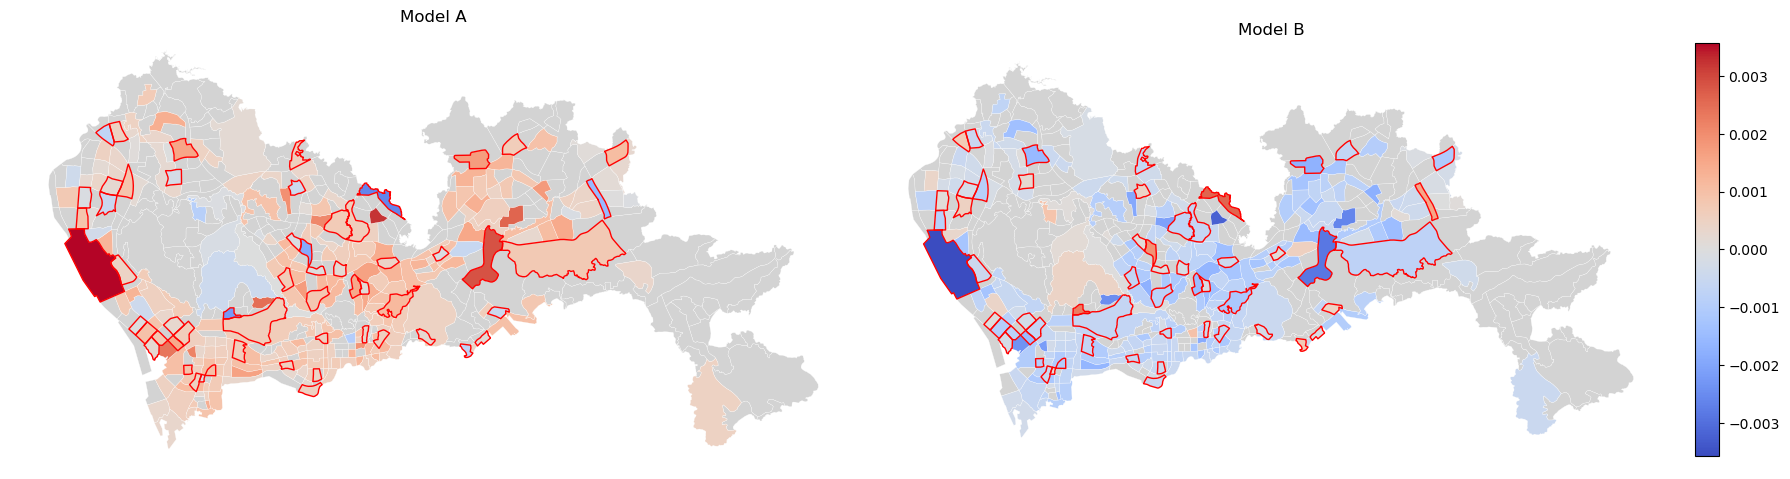

(<Figure size 1800x800 with 3 Axes>,
 array([<Axes: title={'center': 'Model A'}>,
        <Axes: title={'center': 'Model B'}>], dtype=object))

In [43]:
predictions = np.load("../results/pred_20260104_235112_best_post_test.npy")[:412]
pred_20=np.load("./8_10%/pred_20260104_235112_second_best_post_test.npy")

render_7am_map_pair(
    predictions_a=predictions-pred_20,
    predictions_b=pred_20-predictions,
    shp=shp,
    start_hour=12,
    target_hour=8,
    taz_field="TAZID",
    in_csv_field="in_csv",
    in_8_field="in_8",
    cmap="coolwarm",
    title_a="Model A",
    title_b="Model B",
)
# 直接显示 7am 渲染图
# render_7am_map(
#     predictions=predictions,
#     shp=shp,
#     start_hour=12,
#     target_hour=7,
#     taz_field="TAZID",
#     in_csv_field="in_csv",
#     in_8_field="in_8",
#     cmap="Blues",
# )

In [42]:
pred_20-predictions

array([[[-8.83489847e-04,  0.00000000e+00, -2.55265832e-03, ...,
          4.60855663e-04, -5.31092286e-04, -9.39577818e-04],
        [-3.84017825e-03,  2.03829200e-04, -2.07453966e-04, ...,
         -2.04393268e-03, -7.06374645e-04, -3.02602351e-03],
        [ 4.05400991e-04,  2.11525097e-04, -1.11007690e-03, ...,
          2.85076350e-03, -5.47267497e-04,  4.97643650e-03],
        ...,
        [-1.07990205e-02,  0.00000000e+00, -1.24314427e-03, ...,
         -9.54627991e-04, -3.26815993e-04, -7.11396337e-04],
        [-3.90261412e-04,  0.00000000e+00, -2.33173370e-04, ...,
          1.64337456e-04, -3.69474292e-05, -1.56319141e-03],
        [ 3.81886959e-04,  0.00000000e+00, -1.21596456e-03, ...,
          2.02819705e-04,  2.83475965e-04,  8.63432884e-04]],

       [[-2.28750706e-03, -2.95507507e-05, -2.08625197e-03, ...,
         -1.46853179e-03, -8.27088952e-05, -1.98453665e-03],
        [-5.21576405e-03,  6.37339836e-04, -1.25926733e-03, ...,
         -1.22226775e-03, -8.88653100e